<a href="https://colab.research.google.com/github/Meghana-kanne/AIAC/blob/main/2403A52247_LAB_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
johnsmith88_heart_disease_dataset_path = kagglehub.dataset_download('johnsmith88/heart-disease-dataset')

print('Data source import complete.')



**2403A52247   
BATCH-09   
LAB-03**


CSV files found:
/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv

Dataset loaded successfully!

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Shape:
(1025, 14)

Column Names:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.Dat

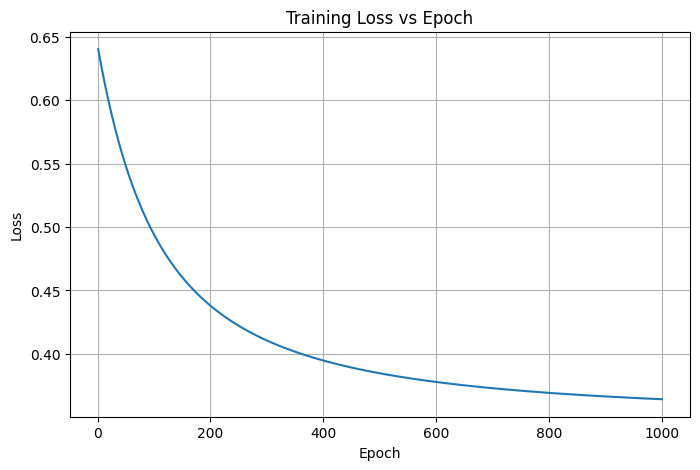



MODEL EVALUATION RESULTS
Accuracy  : 0.8195
Precision : 0.7742
Recall    : 0.9143
F1 Score  : 0.8384

Confusion Matrix:
[[72 28]
 [ 9 96]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.72      0.80       100
     Disease       0.77      0.91      0.84       105

    accuracy                           0.82       205
   macro avg       0.83      0.82      0.82       205
weighted avg       0.83      0.82      0.82       205



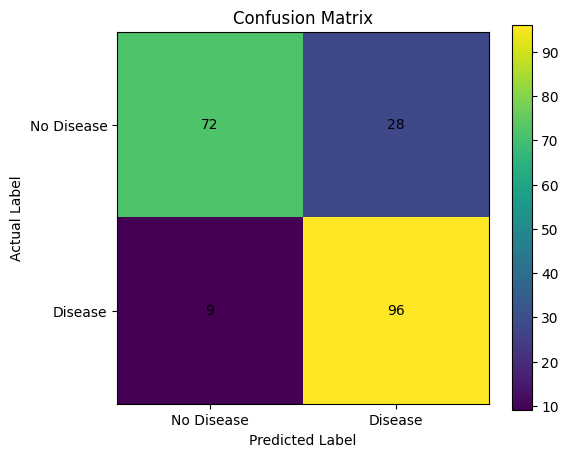


Actual vs Predicted:
    Actual  Predicted
0      0.0        0.0
1      1.0        0.0
2      0.0        0.0
3      1.0        1.0
4      0.0        0.0
5      0.0        0.0
6      1.0        1.0
7      0.0        1.0
8      1.0        1.0
9      1.0        0.0
10     0.0        1.0
11     1.0        1.0
12     0.0        1.0
13     0.0        0.0
14     1.0        1.0
15     0.0        0.0
16     0.0        0.0
17     0.0        0.0
18     0.0        0.0
19     1.0        1.0

Prediction Probabilities:
    Actual  Probability  Predicted
0      0.0     0.026174        0.0
1      1.0     0.369501        0.0
2      0.0     0.021499        0.0
3      1.0     0.724041        1.0
4      0.0     0.243901        0.0
5      0.0     0.041181        0.0
6      1.0     0.820159        1.0
7      0.0     0.541838        1.0
8      1.0     0.935543        1.0
9      1.0     0.369501        0.0
10     0.0     0.684970        1.0
11     1.0     0.871991        1.0
12     0.0     0.541838        1.0

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

csv_files = []

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for file in csv_files:
    print(file)


if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found. Please add the Heart Disease dataset to your Kaggle notebook."
    )


df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")




print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())



if "target" not in df.columns:
    raise ValueError(
        "The dataset does not contain a 'target' column. "
        "Please check the column names."
    )

print("\nTarget Distribution:")
print(df["target"].value_counts())



if df.isnull().sum().sum() > 0:

    print("\nMissing values found.")


    numerical_columns = df.select_dtypes(
        include=np.number
    ).columns

    for column in numerical_columns:
        df[column] = df[column].fillna(
            df[column].median()
        )

    print("Missing values handled.")

else:

    print("\nNo missing values found.")




X = df.drop("target", axis=1)

y = df["target"]

print("\nInput Features:")
print(X.columns)

print("\nNumber of Features:")
print(X.shape[1])

print("\nTarget Values:")
print(y.unique())



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])



scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)


X_test = scaler.transform(X_test)




X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
).reshape(-1, 1)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
).reshape(-1, 1)


print("\nTensor Shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)



class ANNModel(nn.Module):

    def __init__(self, input_features):

        super(ANNModel, self).__init__()


        self.output = nn.Linear(
            input_features,
            1
        )

    def forward(self, x):

        x = self.output(x)


        x = torch.sigmoid(x)

        return x



model = ANNModel(
    X_train.shape[1]
)

print("\nModel Architecture:")
print(model)



criterion = nn.BCELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01
)




epochs = 1000

loss_values = []

for epoch in range(epochs):


    y_pred = model(X_train)



    loss = criterion(
        y_pred,
        y_train
    )



    optimizer.zero_grad()



    loss.backward()



    optimizer.step()


    loss_values.append(
        loss.item()
    )


    if (epoch + 1) % 100 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )



plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_values
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training Loss vs Epoch"
)

plt.grid(True)

plt.show()




model.eval()

with torch.no_grad():


    test_probabilities = model(X_test)



    y_pred = (
        test_probabilities >= 0.5
    ).float()




y_test_np = y_test.numpy().flatten()

y_pred_np = y_pred.numpy().flatten()




accuracy = accuracy_score(
    y_test_np,
    y_pred_np
)

precision = precision_score(
    y_test_np,
    y_pred_np,
    zero_division=0
)

recall = recall_score(
    y_test_np,
    y_pred_np,
    zero_division=0
)

f1 = f1_score(
    y_test_np,
    y_pred_np,
    zero_division=0
)



print("\n")
print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)




cm = confusion_matrix(
    y_test_np,
    y_pred_np
)

print("\nConfusion Matrix:")
print(cm)



print("\nClassification Report:")

print(
    classification_report(
        y_test_np,
        y_pred_np,
        target_names=[
            "No Disease",
            "Disease"
        ],
        zero_division=0
    )
)




plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "Actual Label"
)

plt.xticks(
    [0, 1],
    ["No Disease", "Disease"]
)

plt.yticks(
    [0, 1],
    ["No Disease", "Disease"]
)

# Display values inside matrix
for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()



comparison = pd.DataFrame({

    "Actual": y_test_np,

    "Predicted": y_pred_np

})

print("\nActual vs Predicted:")

print(
    comparison.head(20)
)




probabilities = (
    test_probabilities.numpy().flatten()
)

probability_comparison = pd.DataFrame({

    "Actual": y_test_np,

    "Probability": probabilities,

    "Predicted": y_pred_np

})

print("\nPrediction Probabilities:")

print(
    probability_comparison.head(20)
)




print("\nLearned Weights:")

print(
    model.output.weight.data
)




print("\nLearned Bias:")

print(
    model.output.bias.data
)




print("\n")
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)

print(
    f"Accuracy  : {accuracy * 100:.2f}%"
)

print(
    f"Precision : {precision * 100:.2f}%"
)

print(
    f"Recall    : {recall * 100:.2f}%"
)

print(
    f"F1 Score  : {f1 * 100:.2f}%"
)

print("\nExperiment completed successfully!")